# SHAP Explainability Stability Analysis — CICIDS2017




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os

# Paths
MLP_DIR = "Results/CICIDS2017/MLP/SHAP"
CNN_DIR = "Results/CICIDS2017/CNN/SHAP"
STAB_DIR = "Results/CICIDS2017/Stability"
os.makedirs(STAB_DIR, exist_ok=True)



In [2]:
# Load SHAP global importances
mlp_imp = pd.read_csv(f"{MLP_DIR}/shap_importance.csv")
cnn_imp = pd.read_csv(f"{CNN_DIR}/shap_importance.csv")

print("MLP:", mlp_imp.shape)
print("CNN:", cnn_imp.shape)

mlp_imp.head(), cnn_imp.head()


MLP: (78, 2)
CNN: (78, 2)


(                  feature  importance
 0          PSH Flag Count    0.038389
 1  Packet Length Variance    0.033180
 2          ACK Flag Count    0.031068
 3       Min Packet Length    0.024636
 4           Bwd Packets/s    0.023335,
                   feature  importance
 0  Init_Win_bytes_forward    0.004346
 1        act_data_pkt_fwd    0.004346
 2          PSH Flag Count    0.004346
 3      Packet Length Mean    0.004346
 4             Bwd IAT Std    0.004346)

In [3]:
merged = pd.merge(
    mlp_imp, cnn_imp,
    on="feature",
    suffixes=("_mlp", "_cnn")
)

merged["rank_mlp"] = merged["importance_mlp"].rank(ascending=False)
merged["rank_cnn"] = merged["importance_cnn"].rank(ascending=False)

merged.head()


,feature,importance_mlp,importance_cnn,rank_mlp,rank_cnn
0,PSH Flag Count,0.038389,0.004346,1.0,35.0
1,Packet Length Variance,0.033180,0.004346,2.0,35.0
2,ACK Flag Count,0.031068,0.004346,3.0,35.0
3,Min Packet Length,0.024636,0.004346,4.0,35.0
4,Bwd Packets/s,0.023335,0.004346,5.0,35.0


In [4]:
rho, p = spearmanr(merged["rank_mlp"], merged["rank_cnn"])
rho, p


(np.float64(0.5090717318540547), np.float64(1.9421728994646694e-06))

## 📊 Explainability Stability (Spearman Correlation)

O valor de **ρ (rho)** obtido entre MLP e CNN no dataset CICIDS2017 é:



In [5]:
print(f"Spearman stability (MLP vs CNN) = {rho:.4f}")


Spearman stability (MLP vs CNN) = 0.5091


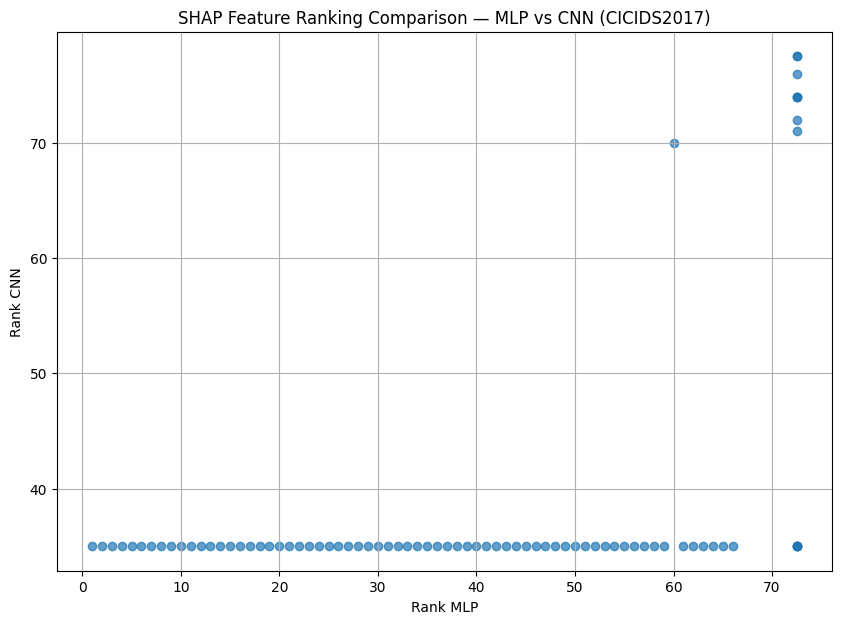

In [6]:
plt.figure(figsize=(10, 7))
plt.scatter(merged["rank_mlp"], merged["rank_cnn"], alpha=0.7)
plt.xlabel("Rank MLP")
plt.ylabel("Rank CNN")
plt.title("SHAP Feature Ranking Comparison — MLP vs CNN (CICIDS2017)")
plt.grid(True)
plt.savefig(f"{STAB_DIR}/stability_scatter_mlp_vs_cnn.png", dpi=200)
plt.show()


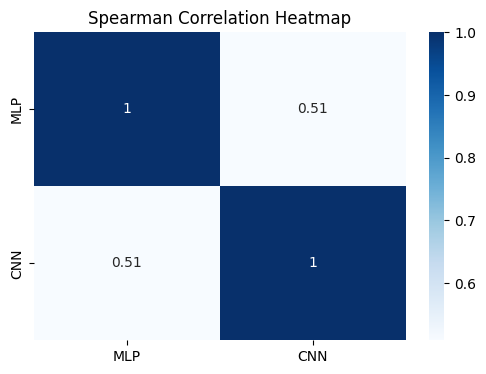

In [7]:
import seaborn as sns

corr_matrix = np.corrcoef(
    [merged["rank_mlp"], merged["rank_cnn"]]
)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="Blues",
            xticklabels=["MLP","CNN"], yticklabels=["MLP","CNN"])
plt.title("Spearman Correlation Heatmap")
plt.savefig(f"{STAB_DIR}/stability_heatmap_mlp_vs_cnn.png", dpi=200)
plt.show()


### Top-K Overlap (Comparação de Rankings)

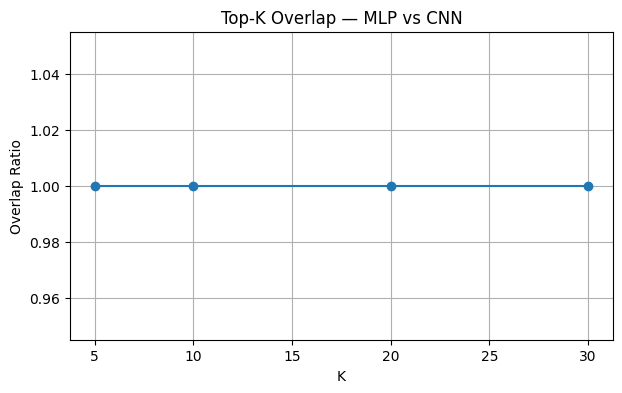

In [8]:
# %% Top-k Overlap — Stability of Top Features

def topk_overlap(r1, r2, k):
    top1 = set(r1.sort_values().index[:k])
    top2 = set(r2.sort_values().index[:k])
    return len(top1 & top2) / k

ks = [5, 10, 20, 30]

overlaps = {k: topk_overlap(merged["rank_mlp"], merged["rank_cnn"], k) for k in ks}
overlaps

# %% Plot Top-K Overlap

plt.figure(figsize=(7, 4))
plt.plot(list(overlaps.keys()), list(overlaps.values()), marker='o')
plt.title("Top-K Overlap — MLP vs CNN")
plt.xlabel("K")
plt.ylabel("Overlap Ratio")
plt.grid(True)
plt.savefig(f"{STAB_DIR}/topk_overlap_mlp_vs_cnn.png", dpi=200)
plt.show()



### Estabilidade Local (Spearman por Instância)

Local Spearman mean: 0.002919616804556935
Local Spearman std: 0.12278950412656611


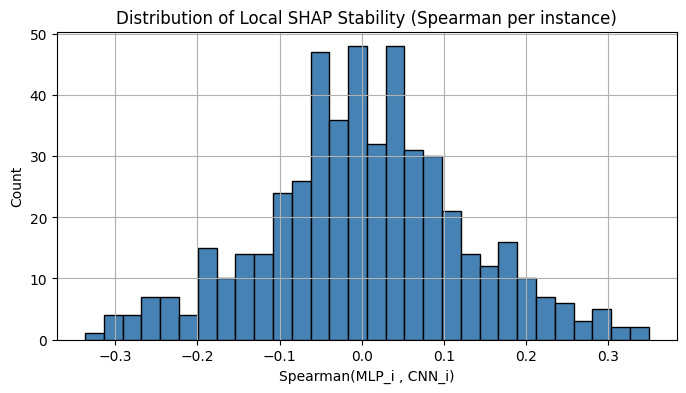

In [9]:
# %% Local SHAP Stability — Instance-Level Spearman

shap_mlp = np.load(f"{MLP_DIR}/shap_values.npy")
shap_cnn = np.load(f"{CNN_DIR}/shap_values.npy")

local_spearman = []
N = min(len(shap_mlp), len(shap_cnn))

for i in range(N):
    rho, _ = spearmanr(shap_mlp[i], shap_cnn[i])
    local_spearman.append(rho)

print("Local Spearman mean:", np.mean(local_spearman))
print("Local Spearman std:", np.std(local_spearman))

# %% Plot Distribution of Local Spearman

plt.figure(figsize=(8,4))
plt.hist(local_spearman, bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Local SHAP Stability (Spearman per instance)")
plt.xlabel("Spearman(MLP_i , CNN_i)")
plt.ylabel("Count")
plt.grid(True)
plt.savefig(f"{STAB_DIR}/distribution_local_spearman_mlp_vs_cnn.png", dpi=200)
plt.show()



### Divergência de Distribuição (Wasserstein EMD por Feature)

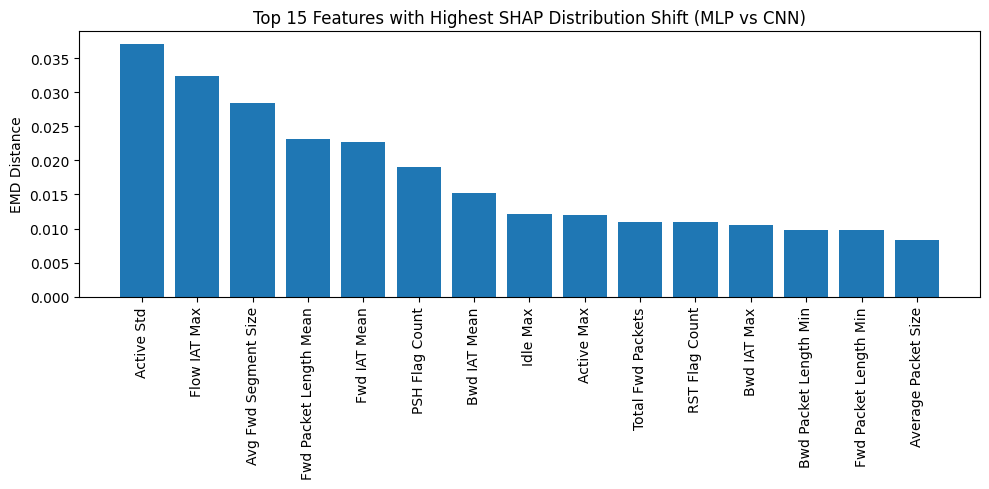

In [10]:
# %% EMD Shift — Distribution Difference of SHAP Values

from scipy.stats import wasserstein_distance

distances = []
for f in range(shap_mlp.shape[1]):
    d = wasserstein_distance(shap_mlp[:, f], shap_cnn[:, f])
    distances.append(d)

feature_shift = pd.DataFrame({
    "feature": merged["feature"],
    "emd_shift": distances
}).sort_values("emd_shift", ascending=False)

feature_shift.head(10)

# %% Plot EMD Shift

plt.figure(figsize=(10, 5))
plt.bar(feature_shift["feature"][:15], feature_shift["emd_shift"][:15])
plt.xticks(rotation=90)
plt.title("Top 15 Features with Highest SHAP Distribution Shift (MLP vs CNN)")
plt.ylabel("EMD Distance")
plt.tight_layout()
plt.savefig(f"{STAB_DIR}/emd_shift_top15_mlp_vs_cnn.png", dpi=200)
plt.show()



### Diferença de Rankings & Diferença de Importância

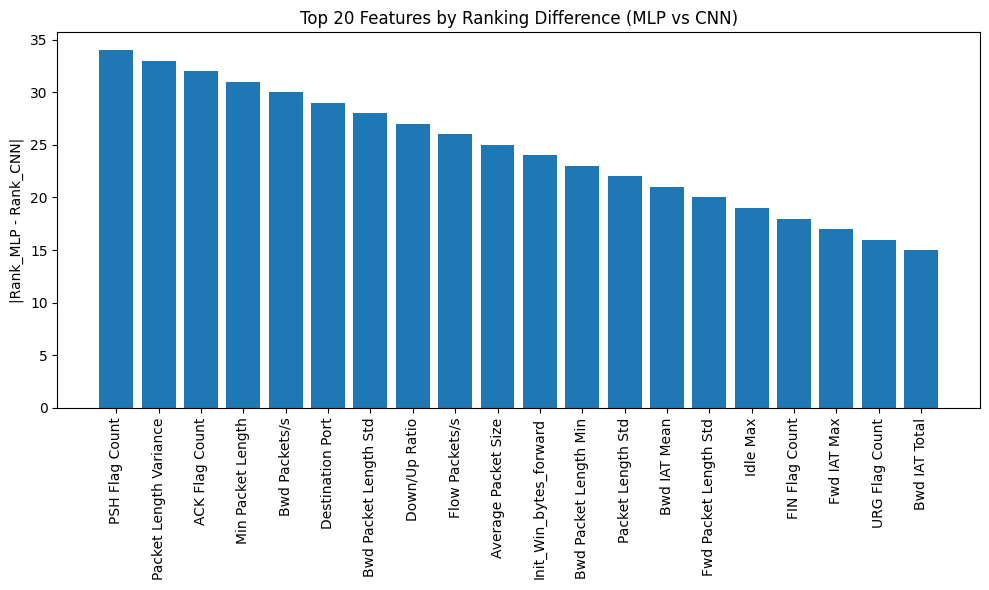

In [11]:
# %% Rank and Importance Differences

merged["rank_diff"] = abs(merged["rank_mlp"] - merged["rank_cnn"])
merged["importance_diff"] = abs(merged["importance_mlp"] - merged["importance_cnn"])

merged[["feature", "rank_diff", "importance_diff"]].head(10)


# %% Plot Rank Differences

plt.figure(figsize=(10,6))
plt.bar(merged["feature"][:20], merged["rank_diff"][:20])
plt.xticks(rotation=90)
plt.title("Top 20 Features by Ranking Difference (MLP vs CNN)")
plt.ylabel("|Rank_MLP - Rank_CNN|")
plt.tight_layout()
plt.savefig(f"{STAB_DIR}/rank_difference_top20_mlp_vs_cnn.png", dpi=200)
plt.show()


### PCA do Espaço SHAP (Comparação das Representações)

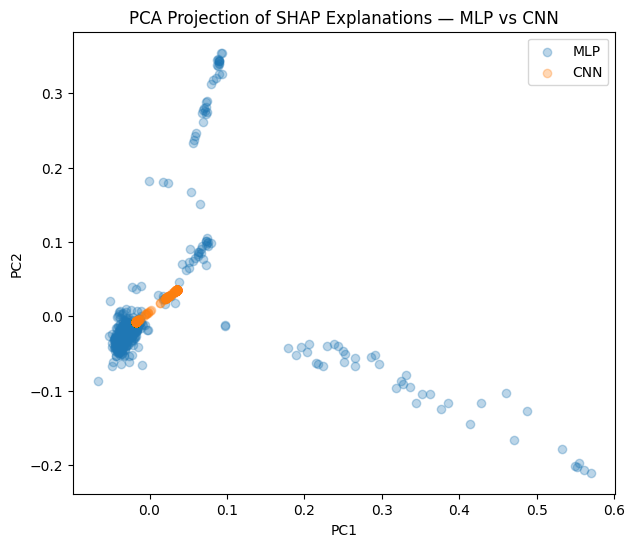

In [12]:
# %% PCA Projection of SHAP Spaces

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
shap_combined = np.vstack([shap_mlp, shap_cnn])

pca.fit(shap_combined)

mlp_2d = pca.transform(shap_mlp)
cnn_2d = pca.transform(shap_cnn)

plt.figure(figsize=(7,6))
plt.scatter(mlp_2d[:,0], mlp_2d[:,1], alpha=0.3, label="MLP")
plt.scatter(cnn_2d[:,0], cnn_2d[:,1], alpha=0.3, label="CNN")
plt.title("PCA Projection of SHAP Explanations — MLP vs CNN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.savefig(f"{STAB_DIR}/pca_shap_mlp_vs_cnn.png", dpi=200)
plt.show()


### Clustering das Explicações (ARI — Divergência Estrutural)

In [13]:
# %% Clustering Similarity for SHAP Explanations (Aligned Sizes)

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Align number of samples
N = min(shap_mlp.shape[0], shap_cnn.shape[0])
shap_mlp_aligned = shap_mlp[:N]
shap_cnn_aligned = shap_cnn[:N]

k = 5  # número de clusters

c1 = KMeans(k, n_init=10).fit(shap_mlp_aligned).labels_
c2 = KMeans(k, n_init=10).fit(shap_cnn_aligned).labels_

ari = adjusted_rand_score(c1, c2)
print("Adjusted Rand Index (MLP vs CNN):", ari)


Adjusted Rand Index (MLP vs CNN): 0.014045570448876516


### Bootstrap Stability (Robustez do Spearman)

In [14]:
# %% Bootstrap Stability of Spearman

def bootstrap_spearman(df, B=50):
    scores = []
    for _ in range(B):
        s = df.sample(frac=0.7, replace=True)
        rho, _ = spearmanr(s["rank_mlp"], s["rank_cnn"])
        scores.append(rho)
    return np.mean(scores), np.std(scores)

mean_rho, std_rho = bootstrap_spearman(merged)
print("Bootstrap Spearman Mean:", mean_rho)
print("Bootstrap Spearman Std:", std_rho)


Bootstrap Spearman Mean: 0.4883592136019979
Bootstrap Spearman Std: 0.07542163973199512


Kendall Tau — robustez alternativa ao Spearman

In [15]:
from scipy.stats import kendalltau

tau, p_tau = kendalltau(merged["rank_mlp"], merged["rank_cnn"])
print(f"Kendall Tau stability = {tau:.4f}   (p={p_tau:.4e})")


Kendall Tau stability = 0.4166   (p=6.5344e-06)


Overlap@K normalizado (estabilidade Top-K ajustada ao acaso)

In [16]:
def random_overlap_expected(n_features, k):
    return k**2 / n_features

for k in [5,10,20,30]:
    top_mlp = set(merged.sort_values("rank_mlp").head(k)["feature"])
    top_cnn = set(merged.sort_values("rank_cnn").head(k)["feature"])
    overlap = len(top_mlp & top_cnn)
    random_exp = random_overlap_expected(len(merged), k)
    print(f"K={k}: overlap={overlap}, expected_random={random_exp:.2f}")


K=5: overlap=5, expected_random=0.32
K=10: overlap=10, expected_random=1.28
K=20: overlap=20, expected_random=5.13
K=30: overlap=30, expected_random=11.54


SHAP Direction Consistency (sinal das explicações)

In [17]:
sign_mlp = np.sign(shap_mlp.mean(axis=0))
sign_cnn = np.sign(shap_cnn.mean(axis=0))

sign_agreement = np.mean(sign_mlp == sign_cnn)
print("Global SHAP sign agreement:", sign_agreement)

changed = merged["feature"][sign_mlp != sign_cnn]
changed.to_list()



Global SHAP sign agreement: 0.5


['PSH Flag Count',
 'Min Packet Length',
 'Bwd Packets/s',
 'Bwd Packet Length Std',
 'Down/Up Ratio',
 'Init_Win_bytes_forward',
 'Bwd Packet Length Min',
 'Fwd Packet Length Std',
 'Bwd IAT Total',
 'Packet Length Mean',
 'Fwd Packets/s',
 'Fwd Packet Length Max',
 'Flow IAT Std',
 'Bwd IAT Std',
 'Flow IAT Mean',
 'Bwd IAT Min',
 'Bwd Packet Length Mean',
 'Avg Bwd Segment Size',
 'Idle Mean',
 'Flow Duration',
 'Fwd IAT Total',
 'Fwd Packet Length Mean',
 'Fwd IAT Std',
 'Fwd PSH Flags',
 'SYN Flag Count',
 'Active Min',
 'Idle Std',
 'act_data_pkt_fwd',
 'Total Length of Bwd Packets',
 'Max Packet Length',
 'Fwd Header Length.1',
 'min_seg_size_forward',
 'Subflow Fwd Bytes',
 'Idle Min',
 'Bwd URG Flags',
 'Bwd Avg Packets/Bulk',
 'Bwd Avg Bytes/Bulk',
 'Fwd Avg Bulk Rate',
 'ECE Flag Count']

Hierarchical Clustering of SHAP — dendrogram

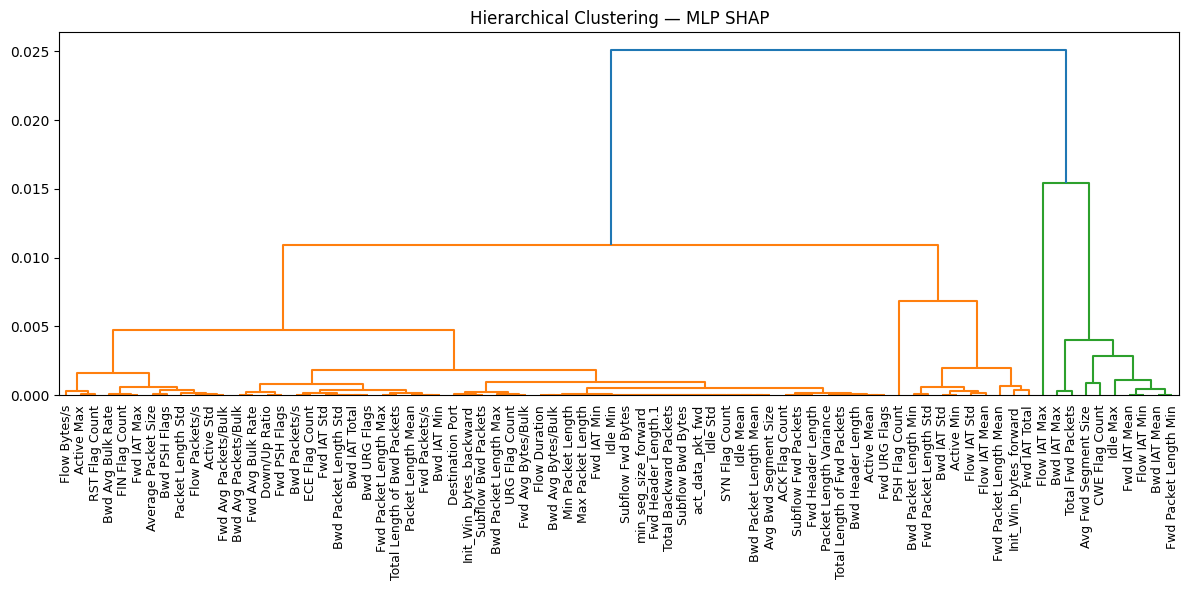

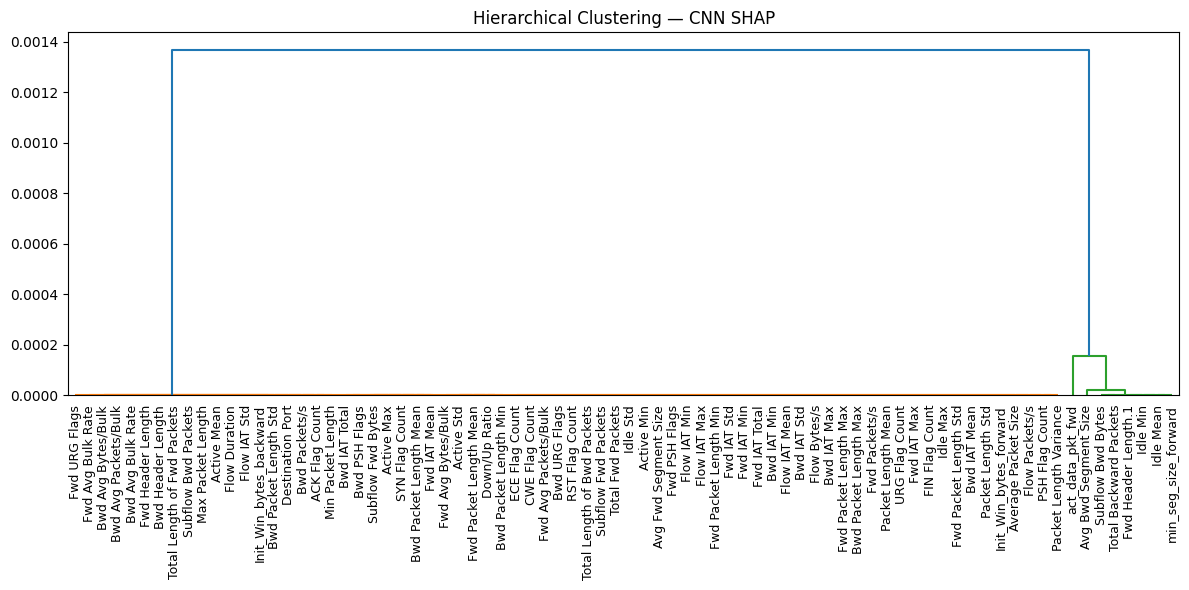

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

features = merged["feature"].values

# Dados: vetor [n_features]
mlp_vec = shap_mlp.mean(axis=0).reshape(-1, 1)
cnn_vec = shap_cnn.mean(axis=0).reshape(-1, 1)

Z_mlp = linkage(mlp_vec, method="ward")
Z_cnn = linkage(cnn_vec, method="ward")

def leaf_label(id):
    return features[id]

plt.figure(figsize=(12, 6))
dendrogram(Z_mlp, leaf_rotation=90, leaf_font_size=9,
           labels=None, leaf_label_func=leaf_label)
plt.title("Hierarchical Clustering — MLP SHAP")
plt.tight_layout()
plt.savefig(f"{STAB_DIR}/dendrogram_mlp_shap.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 6))
dendrogram(Z_cnn, leaf_rotation=90, leaf_font_size=9,
           labels=None, leaf_label_func=leaf_label)
plt.title("Hierarchical Clustering — CNN SHAP")
plt.tight_layout()
plt.savefig(f"{STAB_DIR}/dendrogram_cnn_shap.png", dpi=200)
plt.show()


Rank Stability Curve (inspirado em métricas de IR)

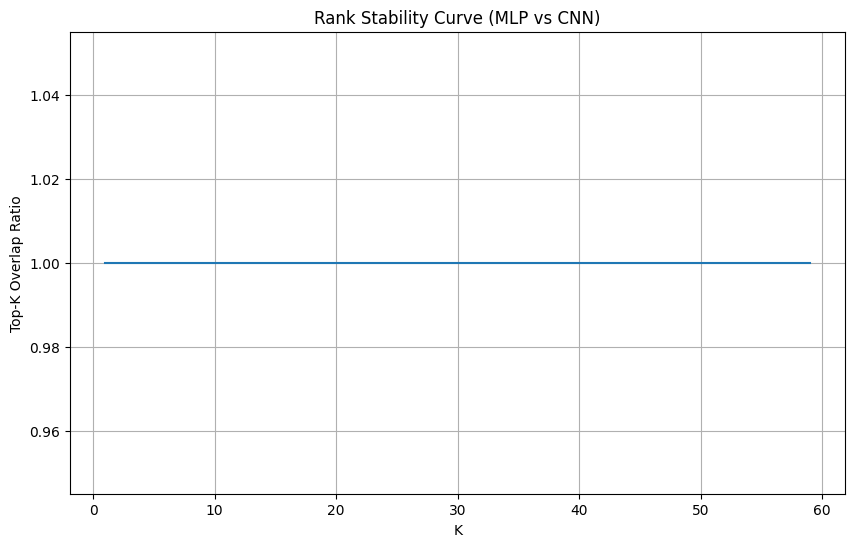

In [19]:
Ks = range(1, 60)
stability_curve = []

for k in Ks:
    top_mlp = set(merged.sort_values("rank_mlp").head(k)["feature"])
    top_cnn = set(merged.sort_values("rank_cnn").head(k)["feature"])
    stability_curve.append(len(top_mlp & top_cnn) / k)

plt.figure(figsize=(10,6))
plt.plot(Ks, stability_curve)
plt.xlabel("K")
plt.ylabel("Top-K Overlap Ratio")
plt.title("Rank Stability Curve (MLP vs CNN)")
plt.grid(True)
plt.savefig(f"{STAB_DIR}/stability_curve_mlp_vs_cnn.png", dpi=200)
plt.show()


In [20]:
merged.to_csv(f"{STAB_DIR}/stability_rank_table.csv", index=False)
print("Saved stability table.")


Saved stability table.
